<a href="https://colab.research.google.com/github/pachterlab/varseek-examples/blob/main/vk_denovo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [vk denovo](https://github.com/pachterlab/varseek) demonstration
Call de novo variants from scRNA-seq reads, build a varseek reference from those variants, and count variant-supporting reads with vk count. This notebook uses a [10x PBMC 1k dataset](https://www.10xgenomics.com/datasets/1-k-pbm-cs-from-a-healthy-donor-v-3-chemistry-3-standard-3-0-0) as an example.

Written by Joseph Rich.
___


### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import re
import anndata as ad
import pandas as pd
import pysam

import varseek as vk

### Define important paths

In [3]:
# input files
fastqs_dir = os.path.join("data", "pbmc_1k_v3_fastqs")
technology = "10xv3"
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "Homo_sapiens.GRCh38.dna.primary_assembly.fa")
gtf = os.path.join(reference_dir, "Homo_sapiens.GRCh38.114.gtf")

# vk denovo out
variants_dir = os.path.join("data", "pbmc_1k_v3_variants")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
denovo_bam_dir = os.path.join(variants_dir, "bams")
star_genome_index_dir = os.path.join(reference_dir, "star_index")
denovo_star_alignment_dir = os.path.join(variants_dir, "star_alignments")

# vk ref out
vk_ref_out_dir = os.path.join("data", "varseek_ref_out_pbmc_1k_v3")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")

# vk count out
vk_count_out_dir = os.path.join("data", "varseek_count_out_pbmc_1k_v3")
vk_count_variants_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")

# general parameters
w = 37
k = 41
min_counts_denovo = 3
threads = 16
min_counts_clean = 1

### Download the PBMC fastq dataset

In [4]:
if not os.path.exists(fastqs_dir) or len(os.listdir(fastqs_dir)) == 0:
    !mkdir -p data && \
        cd data && \
        curl -O https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_1k_v3/pbmc_1k_v3_fastqs.tar && \
        tar -xvf pbmc_1k_v3_fastqs.tar && \
        rm pbmc_1k_v3_fastqs.tar

### Download the reference genome (GRCh38, Ensembl 114, cDNA file)

In [5]:
if not os.path.exists(sequences):
    !gget ref -w dna -r 114 --out_dir {reference_dir} -d human
    !gunzip {sequences}.gz

if not os.path.exists(gtf):
    !gget ref -w gtf -r 114 --out_dir {reference_dir} -d human
    !gunzip {gtf}.gz

### Run varseek denovo

In [6]:
fastq_r2_files = sorted(
    os.path.join(root, file)
    for root, _, files in os.walk(fastqs_dir)
    for file in files
    if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and "_R2_" in file
)

if not os.path.exists(variants):
    vk.denovo(
        inputs=fastq_r2_files,
        fasta_ref=sequences,
        gtf=gtf,
        aligner="STAR",
        star_genome_index_dir=star_genome_index_dir,
        star_alignment_prefix=f"{denovo_star_alignment_dir}/star_",
        out_bam_dir=denovo_bam_dir,
        output=variants_vcf,
        output_tsv=variants,
        min_counts=min_counts_denovo,
        threads=threads,
        read_length=91,
        verbose=1,
    )


variants_df = pd.read_csv(variants, sep="\t")
print(f"Number of variants: {len(variants_df)}")
variants_df.head()

Number of variants: 325576


/home/jrich/tmp/ipykernel_3901444/3070598833.py:26: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  variants_df = pd.read_csv(variants, sep="\t")


,seq_id,variant
0,1,g.199391G>A
1,1,g.511638T>C
2,1,g.511644T>C
3,1,g.511685T>C
4,1,g.511693T>C


### Run varseek ref

In [7]:
if not os.path.exists(vcrs_index):
    vk_ref_output_dict = vk.ref(
        variants=variants,
        sequences=sequences,
        seq_id_column="seq_id",
        var_column="variant",
        out=vk_ref_out_dir,
        reference_out_dir=reference_dir,
        dlist_reference_source="t2t",
        index_out=vcrs_index,
        t2g_out=vcrs_t2g,
        w=w,
        k=k
    )

### Run varseek count

This will run the following commands:
- `varseek fastqpp`: Preprocess the fastq files. By default, does nothing.
- `kb count` (variant reference): Perform variant screening on fastq data utilizing kb count's pseudoalignment algorithm. Variant data is stored in an Anndata object as as cell/sample x variant matrix.
- `kb count` ("normal" reference genome) (optional): Perform pseudoalignment of fastq data to the reference genome. Only performed if utilized in the subsequence "varseek clean" step. By default, will occur if the path to the necessary files are not provided as input.
- `varseek clean`: Process the output of kb count. By default, this will threshold variant counts and ensure that there is agreement for each read between the gene of the variant to which the read aligned during the variant reference pseudoalignment and the gene to which the read aligned during the "normal" reference genome pseudoalignment.
- `varseek summarize`: Produces a text file summarizing some high-level insights from the variant screening process.

In [8]:
vk_count_output_dict = vk.count(
    fastqs_dir,
    index=vcrs_index,
    t2g=vcrs_t2g,
    technology=technology,
    out=vk_count_out_dir,
    k=k,
    threads=threads,
    strand="unstranded",
    min_counts=min_counts_clean,
    save_vcf=True
)

11:21:21 - INFO - Removing index files from fastq files list, as they are not utilized in kb count with technology 10XV3
11:21:21 - INFO - File data/pbmc_1k_v3_fastqs/combined_R2.fastq.gz does not match the Illumina file naming convention of SAMPLE_LANE_R[12]_001.fastq.gz, so removing it from the fastq files list.
11:21:21 - INFO - Setting length_required to 41 if fastqpp is run
11:21:21 - INFO - Skipping vk fastqpp because there was no use for it
11:21:21 - INFO - Skipping kb count because file data/varseek_count_out_pbmc_1k_v3/kb_count_out_vcrs/counts_unfiltered/adata.h5ad already exists and overwrite=False
11:21:21 - INFO - Skipping kb count for reference genome because the reference genome adata object was not needed and/or the file 'data/varseek_count_out_pbmc_1k_v3/kb_count_out_reference_genome/counts_unfiltered/adata.h5ad' already exists. Note that even setting overwrite=True will still not overwrite this particular file.
11:21:21 - INFO - Skipping vk clean because file data/var

In [9]:
# adata = ad.read_h5ad(vk_count_output_dict["adata_path_unprocessed"])
# adata.var.head()

In [10]:
print(f"Find the processed adata object for further analysis in {vk_count_output_dict['adata_path']}")

Find the processed adata object for further analysis in /home/jrich/Desktop/varseek-examples/data/varseek_count_out_pbmc_1k_v3/adata_cleaned.h5ad


In [11]:
varseek_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")
if not os.path.exists(varseek_vcf):
    adata_path = vk_count_output_dict['adata_path']  #  if not use_unfiltered_varseek else vk_count_output_dict['adata_path_unprocessed']
    adata = ad.read_h5ad(adata_path)
    adata = adata[:, adata.X.sum(axis=0) > 0]  # filter to only keep variants present in at least 1 cell
    variants = adata.var_names.tolist()

    # Reference genome FASTA
    fasta = pysam.FastaFile(sequences)

    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})

    # Flatten grouped variants (joined by ";") into one Series, preserving the
    # original order so the written VCF matches the old per-variant loop.
    var_series = pd.Series(variants, dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)

    # Vectorized HGVS parsing: every variant is exactly one of three forms.
    # str.extract returns NaN for every group on a non-matching row, so a
    # notna() check on a required group acts as the per-type mask.
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")

    snv_mask = snv["CHROM"].notna()
    ins_mask = ins["CHROM"].notna()
    del_mask = dele["START"].notna()

    for var in var_series[~(snv_mask | ins_mask | del_mask)]:
        print(f"Could not parse: {var}")

    frames = []

    # --- Substitutions (no reference lookup needed) ---
    snv = snv[snv_mask & snv["CHROM"].isin(chromosomes)]
    if not snv.empty:
        frames.append(pd.DataFrame({
            "CHROM": snv["CHROM"],
            "POS": snv["POS"].astype(int),
            "REF": snv["REF"],
            "ALT": snv["ALT"],
        }, index=snv.index))

    # --- Insertions: prepend the left anchor base from the reference ---
    ins = ins[ins_mask & ins["CHROM"].isin(chromosomes)]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series(
            [fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)],
            index=ins.index,
        )
        frames.append(pd.DataFrame({
            "CHROM": ins["CHROM"],
            "POS": ins_pos,
            "REF": anchor,
            "ALT": anchor + ins["INS"],
        }, index=ins.index))

    # --- Deletions: anchor base before the deletion; fetch the deleted bases
    #     from the reference when HGVS omits them (e.g. "g.123del") ---
    dele = dele[del_mask & dele["CHROM"].isin(chromosomes)]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series(
            [fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)],
            index=dele.index,
        )
        deleted = pd.Series(
            [d if d != "" else fasta.fetch(c, s - 1, e)
             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])],
            index=dele.index,
        )
        frames.append(pd.DataFrame({
            "CHROM": dele["CHROM"],
            "POS": start - 1,
            "REF": anchor + deleted,
            "ALT": anchor,
        }, index=dele.index))

    # Concatenate all variant types and restore the original variant order.
    vcf_df = (pd.concat(frames).sort_index()
              if frames else pd.DataFrame(columns=["CHROM", "POS", "REF", "ALT"]))

    # Build every data line with vectorized string ops, then write in one shot.
    lines = (
        vcf_df["CHROM"].astype(str) + "\t"
        + vcf_df["POS"].astype(str) + "\t.\t"
        + vcf_df["REF"] + "\t"
        + vcf_df["ALT"] + "\t.\t.\t.\n"
    )

    with open(varseek_vcf, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.write("".join(lines))

    print(f"Wrote {len(vcf_df):,} variants to {varseek_vcf}")


Wrote 230,671 variants to data/varseek_count_out_pbmc_1k_v3/varseek_variants.vcf


In [12]:
fastq_r2_file_combined = os.path.join(fastqs_dir, "combined_R2.fastq.gz")
if not os.path.exists(fastq_r2_file_combined):
    r2_files = sorted(
        os.path.join(root, file)
        for root, _, files in os.walk(fastqs_dir)
        for file in files
        if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and "_R2_" in file
    )
    with open(fastq_r2_file_combined, "wb") as wfd:
        for r2_file in r2_files:
            with open(r2_file, "rb") as fd:
                wfd.write(fd.read())

In [13]:
genomes1000_vcf = os.path.join(reference_dir, "1000GENOMES-phase_3.vcf")
picard_jar = "/home/jrich/opt/picard.jar"
gatk_out = os.path.join("data", "gatk_out")
tmp_dir = os.path.join("data", "tmp")

if not os.path.exists(tmp_dir):
    os.makedirs(tmp_dir)

if not os.path.exists(genomes1000_vcf):
    !wget -O {genomes1000_vcf}.gz "https://ftp.ensembl.org/pub/release-114/variation/vcf/homo_sapiens/1000GENOMES-phase_3.vcf.gz"
    !gunzip {genomes1000_vcf}.gz

In [14]:
model_dir = os.path.join("data", "deepvariant_model")
deepvariant_vcf = os.path.join(gatk_out, "vcf_output", "deepvariant_variants.vcf.gz")

if not os.path.exists(deepvariant_vcf):
    !echo python /home/jrich/Desktop/RLSRP_2025/scripts/run_deepvariant_for_benchmarking.py \
        --synthetic_read_fastq {fastq_r2_file_combined} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length 91 \
        --model_dir {model_dir} \
        --docker podman \
        --out {gatk_out} \
        --skip_accuracy_analysis

In [15]:
haplotypecaller_vcf = os.path.join(gatk_out, "vcfs", "haplotypecaller", "haplotypecaller_output_filtered_applied.vcf.gz")

if not os.path.exists(haplotypecaller_vcf):
    !echo python /home/jrich/Desktop/RLSRP_2025/scripts/run_gatk_haplotypecaller_for_benchmarking.py \
        --synthetic_read_fastq {fastq_r2_file_combined} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length 91 \
        --picard_jar {picard_jar} \
        --threads {threads} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis

In [16]:
mutect2_vcf = os.path.join(gatk_out, "vcfs", "mutect2", "mutect2_output_filtered_applied.vcf.gz")

# PYTHONBREAKPOINT=0 disables the stray breakpoint() in the script for non-interactive runs.
# --java points GATK/Picard at JDK 17.
if not os.path.exists(mutect2_vcf):
    !PYTHONBREAKPOINT=0 python /home/jrich/Desktop/RLSRP_2025/scripts/run_gatk_mutect2_for_benchmarking.py \
        --synthetic_read_fastq {fastq_r2_file_combined} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length 91 \
        --picard_jar {picard_jar} \
        --java "/home/jrich/opt/jdk-17.0.12+7/bin/java" \
        --threads {threads} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis

In [17]:
import os
import gzip
import subprocess

def is_vcf_normalized(vcf_path):
    """
    Returns True if the VCF has a header line indicating bcftools norm was run.
    """
    # Auto-detect if compressed
    open_func = gzip.open if vcf_path.endswith(".gz") else open

    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("##bcftools_normCommand="):
                return True
            # Headers always start with ##
            if not line.startswith("##"):
                # Stop at the column header line
                break
    return False

def ensure_genotype_column(vcf_path, sample_name="SAMPLE", genotype="1/1"):
    """hap.py requires at least one sample carrying genotypes. varseek emits a
    sites-only VCF (CHROM..INFO only), so inject a placeholder FORMAT/GT column
    if none is present. No-op for VCFs that already have sample columns."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open

    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()

    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return  # FORMAT + sample columns already present
            break

    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    new_lines = []
    inserted_header = False
    for line in lines:
        if line.startswith("##"):
            new_lines.append(line)
        elif line.startswith("#CHROM"):
            if not inserted_header:
                new_lines.append(gt_header)
                inserted_header = True
            cols = line.rstrip("\n").split("\t") + ["FORMAT", sample_name]
            new_lines.append("\t".join(cols) + "\n")
        elif line.strip():
            cols = line.rstrip("\n").split("\t") + ["GT", genotype]
            new_lines.append("\t".join(cols) + "\n")

    with open(vcf_path, "wt") as f:
        f.writelines(new_lines)

def insert_suffix_before_first_dot(path, suffix):
    dirname, basename = os.path.split(path)
    if "." in basename:
        parts = basename.split(".", 1)
        new_basename = parts[0] + suffix + "." + parts[1]
    else:
        new_basename = basename + suffix
    return os.path.join(dirname, new_basename)

def add_normalized_before_first_dot(path):
    return insert_suffix_before_first_dot(path, "_normalized")

def _vcf_has_samples(vcf_path):
    """True if the VCF carries FORMAT + per-sample genotype columns (i.e. the
    #CHROM header line has more than the 8 fixed columns)."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                return len(line.rstrip("\n").split("\t")) > 8
            if not line.startswith("#"):
                break
    return False

def filter_to_variant_calls(vcf_path):
    """Keep only records where the sample actually carries an ALT allele, dropping
    hom-ref (0/0) and no-call (./.) records -- e.g. DeepVariant 'RefCall' sites,
    which make up the bulk of its output. Left in, these non-variant records
    dominate the hap.py query totals and collapse precision. The FILTER column is
    preserved so hap.py can still stratify ALL vs PASS."""
    # Sites-only VCFs (no FORMAT/sample columns, e.g. varseek or VarTrix) carry no
    # genotypes, so a GT="alt" filter would error ("tag GT is not defined"). There
    # is nothing to drop -- every record is already a variant site -- so pass the
    # VCF through unchanged (and skip the _nonref suffix downstream).
    if not _vcf_has_samples(vcf_path):
        return vcf_path

    out_path = insert_suffix_before_first_dot(vcf_path, "_nonref")

    if os.path.isfile(out_path) and os.path.getsize(out_path) > 0:
        print(f"Filtered file {out_path} already exists. Skipping filtering.")
    else:
        output_type = "-Oz" if out_path.endswith(".vcf.gz") else "-Ov"
        subprocess.run(
            ["bcftools", "view", "-i", 'GT="alt"', output_type, "-o", out_path, vcf_path],
            check=True,
        )
    return out_path

def make_normalized_vcf(test_vcf, reference_fasta):
    test_vcf_unnormalized = test_vcf
    test_vcf = add_normalized_before_first_dot(test_vcf_unnormalized)

    # Treat a zero-byte file as missing: a previous bcftools failure can leave an
    # empty output behind, and a plain isfile() check would silently reuse it.
    if os.path.isfile(test_vcf) and os.path.getsize(test_vcf) > 0:
        print(f"Normalized file {test_vcf} already exists. Skipping normalization.")
    else:
        reference_fasta_index = f"{reference_fasta}.fai"
        if not os.path.isfile(reference_fasta_index):
            subprocess.run(["samtools", "faidx", reference_fasta], check=True)

        output_type = "-Oz" if test_vcf.endswith(".vcf.gz") else "-Ov"
        # Pipeline: reheader -> norm -> sort.
        #  * reheader --fai: the varseek VCF carries no ##contig header lines, which
        #    makes `bcftools norm` abort with "CONTIG id not present in the header"
        #    and leaves an empty file. Add/refresh contig lines from the reference.
        #  * norm: left-align, split multiallelics, check against the reference.
        #  * sort: the varseek records are not grouped by chromosome, so tabix
        #    indexing later fails with "chromosome blocks not continuous".
        reheader_proc = subprocess.Popen(
            ["bcftools", "reheader", "--fai", reference_fasta_index, test_vcf_unnormalized],
            stdout=subprocess.PIPE,
        )
        norm_proc = subprocess.Popen(
            ["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
            stdin=reheader_proc.stdout, stdout=subprocess.PIPE,
        )
        reheader_proc.stdout.close()
        subprocess.run(["bcftools", "sort", output_type, "-o", test_vcf], stdin=norm_proc.stdout, check=True)
        norm_proc.stdout.close()
        if reheader_proc.wait() != 0:
            raise subprocess.CalledProcessError(reheader_proc.returncode, "bcftools reheader")
        if norm_proc.wait() != 0:
            raise subprocess.CalledProcessError(norm_proc.returncode, "bcftools norm")

    # sites-only VCFs (e.g. varseek) need a placeholder genotype for hap.py
    ensure_genotype_column(test_vcf)

    if test_vcf.endswith(".gz") and not os.path.isfile(f"{test_vcf}.tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", test_vcf], check=True)

    return test_vcf

def compare_with_happy(varseek_vcf, alternate_vcf, reference_fasta, output_dir, output_prefix="happy"):
    varseek_vcf = os.path.abspath(varseek_vcf)
    alternate_vcf = os.path.abspath(alternate_vcf)
    reference_fasta = os.path.abspath(reference_fasta)
    output_dir = os.path.abspath(output_dir)
    
    varseek_vcf_dir = os.path.dirname(varseek_vcf)
    alternate_vcf_dir = os.path.dirname(alternate_vcf)
    reference_fasta_dir = os.path.dirname(reference_fasta)

    reference_fasta_index = f"{reference_fasta}.fai"
    if not os.path.isfile(reference_fasta_index):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)

    # Drop non-variant (hom-ref / no-call) records from the caller VCF before
    # comparison; varseek emits only variant sites so it needs no such filter.
    alternate_vcf = filter_to_variant_calls(alternate_vcf)

    if not is_vcf_normalized(alternate_vcf):
        alternate_vcf = make_normalized_vcf(alternate_vcf, reference_fasta)

    if not is_vcf_normalized(varseek_vcf):
        varseek_vcf = make_normalized_vcf(varseek_vcf, reference_fasta)

    summary_csv_path = os.path.join(output_dir, f"{output_prefix}.summary.csv")

    if os.path.isfile(summary_csv_path):
        print(f"Summary file {summary_csv_path} already exists. Skipping hap.py run.")
    else:
        os.makedirs(output_dir, exist_ok=True)
        output_prefix_full = os.path.join(output_dir, output_prefix)
        command = f"podman run --rm -v {varseek_vcf_dir}:{varseek_vcf_dir} -v {alternate_vcf_dir}:{alternate_vcf_dir} -v {reference_fasta_dir}:{reference_fasta_dir} -v {output_dir}:{output_dir} mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py -r {reference_fasta} --engine=scmp-somatic -o {output_prefix_full} {varseek_vcf} {alternate_vcf}"
        subprocess.run(command, shell=True, check=True)


In [19]:
happy_out = os.path.join("data", "happy_output")
# if not use_unfiltered_varseek:
#     happy_out += "_filtered"

for label, alternate_vcf in [("deepvariant", deepvariant_vcf), ("haplotypecaller", haplotypecaller_vcf), ("mutect2", mutect2_vcf)]:
    if not os.path.exists(alternate_vcf):
        print(f"Alternate VCF {alternate_vcf} does not exist. Skipping comparison for {label}.")
        continue
    compare_with_happy(
        varseek_vcf=vk_count_variants_vcf,
        alternate_vcf=alternate_vcf,
        reference_fasta=sequences,
        output_dir=happy_out,
        output_prefix=f"varseek_vs_{label}"
    )

Filtered file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcf_output/deepvariant_variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz already exists. Skipping normalization.


Writing to /home/jrich/tmp/bcftools.Uio1DX
Lines   total/split/joined/realigned/removed/skipped:	230671/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning


Summary file /home/jrich/Desktop/varseek-examples/data/happy_output/varseek_vs_deepvariant.summary.csv already exists. Skipping hap.py run.
Filtered file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz already exists. Skipping normalization.
Normalized file /home/jrich/Desktop/varseek-examples/data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf already exists. Skipping normalization.
Summary file /home/jrich/Desktop/varseek-examples/data/happy_output/varseek_vs_haplotypecaller.summary.csv already exists. Skipping hap.py run.
Filtered file /home/jrich/Desktop/varseek-examples/data/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file /home/jrich/

In [20]:
# Collect the hap.py summary tables into one view.
# varseek is the TRUTH set and each caller is the QUERY, so:
#   Recall    = fraction of varseek calls confirmed by the caller
#   Precision = fraction of the caller's calls also in varseek (low by design:
#               varseek reports a small targeted subset vs. a genome-wide caller)
summary_frames = []
for label, alternate_vcf in [("deepvariant", deepvariant_vcf), ("haplotypecaller", haplotypecaller_vcf), ("mutect2", mutect2_vcf)]:
    summary_csv_path = os.path.join(happy_out, f"varseek_vs_{label}.summary.csv")
    if not os.path.isfile(summary_csv_path):
        continue
    df = pd.read_csv(summary_csv_path)
    df.insert(0, "Caller", label)
    summary_frames.append(df)

if summary_frames:
    summary_all = pd.concat(summary_frames, ignore_index=True)
    cols = ["Caller", "Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN",
            "QUERY.TOTAL", "QUERY.FP", "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
    display(summary_all[cols])
else:
    print("No hap.py summaries found yet -- run the comparison cell above first.")


,Caller,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,deepvariant,INDEL,ALL,9408,7548,1860,37432,29849,0.802296,0.202581,0.323482
1,deepvariant,INDEL,PASS,9408,7548,1860,37432,29849,0.802296,0.202581,0.323482
2,deepvariant,SNP,ALL,172971,83971,89000,175480,91544,0.485463,0.478322,0.481866
3,deepvariant,SNP,PASS,172971,83971,89000,175480,91544,0.485463,0.478322,0.481866
4,haplotypecaller,INDEL,ALL,9408,7820,1588,41463,33587,0.831207,0.189952,0.309236
5,haplotypecaller,INDEL,PASS,9408,7820,1588,41463,33587,0.831207,0.189952,0.309236
6,haplotypecaller,SNP,ALL,172971,100864,72107,213412,112604,0.583127,0.472363,0.521933
7,haplotypecaller,SNP,PASS,172971,100864,72107,213412,112604,0.583127,0.472363,0.521933
8,mutect2,INDEL,ALL,9408,6380,3028,29165,22765,0.678146,0.219441,0.331585
9,mutect2,INDEL,PASS,9408,6380,3028,29165,22765,0.678146,0.219441,0.331585


In [21]:
# rename 'TRUTH' to 'VARSEEK' and 'QUERY' to 'CALLER' for clarity in this benchmarking context where varseek is the truth set and the other callers are the queries.
display(summary_all[['Caller', 'Type', 'Filter', 'METRIC.Recall', 'METRIC.Precision']])

,Caller,Type,Filter,METRIC.Recall,METRIC.Precision
0,deepvariant,INDEL,ALL,0.802296,0.202581
1,deepvariant,INDEL,PASS,0.802296,0.202581
2,deepvariant,SNP,ALL,0.485463,0.478322
3,deepvariant,SNP,PASS,0.485463,0.478322
4,haplotypecaller,INDEL,ALL,0.831207,0.189952
5,haplotypecaller,INDEL,PASS,0.831207,0.189952
6,haplotypecaller,SNP,ALL,0.583127,0.472363
7,haplotypecaller,SNP,PASS,0.583127,0.472363
8,mutect2,INDEL,ALL,0.678146,0.219441
9,mutect2,INDEL,PASS,0.678146,0.219441


### Upset plot: variant call overlap across callers

Compare the variant call sets of varseek, DeepVariant, GATK HaplotypeCaller, and GATK Mutect2 as an upset plot, using the normalized VCFs so all callers share a common coordinate representation.

In [22]:
variants_vcf_filtered = filter_to_variant_calls(variants_vcf)
_ = make_normalized_vcf(variants_vcf_filtered, sequences)

Filtered file data/pbmc_1k_v3_variants/variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/pbmc_1k_v3_variants/variants_nonref_normalized.vcf.gz already exists. Skipping normalization.


varseek: 230,671 variants (data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf)
deepvariant: 212,975 variants (data/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz)
haplotypecaller: 255,026 variants (data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz)
mutect2: 289,308 variants (data/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz)
bcftools: 325,399 variants (data/pbmc_1k_v3_variants/variants_nonref_normalized.vcf.gz)
Saved upset plot to data/happy_output/upset_callers.png


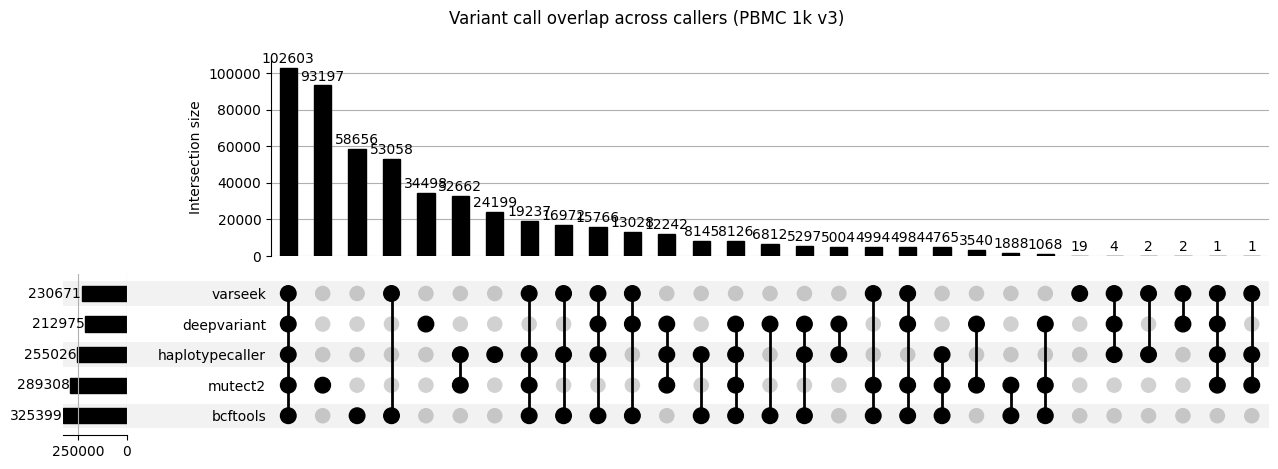

In [23]:
try:
    import upsetplot
except ImportError:
    print("upsetplot not found, installing...")
    !pip install -U -q upsetplot
    import upsetplot

import gzip
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet


def read_variant_set(vcf_path):
    """Read a (optionally gzipped) VCF into a set of (CHROM, POS, REF, ALT) keys.
    Multiallelic ALTs are split so each allele is counted separately."""
    if not vcf_path or not os.path.exists(vcf_path):
        return None
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    keys = set()
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            for a in alt.split(","):
                keys.add((chrom, pos, ref, a))
    return keys


# Use the normalized (left-aligned, multiallelic-split) VCFs so all four callers
# share a common coordinate representation. varseek is a variant-sites-only set;
# the GATK/DeepVariant callers are filtered to non-reference calls (_nonref) before
# normalization inside compare_with_happy().
caller_vcfs = {
    "varseek": add_normalized_before_first_dot(vk_count_variants_vcf),
    "deepvariant": add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "mutect2": add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref")),
    "bcftools": add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref"))
}

caller_sets = {}
for name, path in caller_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from upset plot.")
        continue
    caller_sets[name] = s
    print(f"{name}: {len(s):,} variants ({path})")

if len(caller_sets) >= 2:
    upset_data = from_contents(caller_sets)
    fig = plt.figure(figsize=(11, 6))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality", sort_categories_by="-input").plot(fig=fig)
    fig.suptitle("Variant call overlap across callers (PBMC 1k v3)")

    upset_png = os.path.join(happy_out, "upset_callers.png")
    os.makedirs(happy_out, exist_ok=True)
    fig.savefig(upset_png, dpi=150, bbox_inches="tight")
    print(f"Saved upset plot to {upset_png}")
    plt.show()
else:
    print("Need at least two caller sets to build an upset plot.")

### Benchmark against VarTrix

[VarTrix](https://github.com/10XGenomics/vartrix) genotypes a set of pre-called variants against a single-cell BAM, producing a cell × variant matrix of ref/alt read support — the single-cell analog of `vk count`. Here we feed it the de novo variants called above (`variants.vcf.gz`, the VCF form of `variants.tsv`).

VarTrix requires a Cell Ranger-style BAM carrying `CB` (cell barcode) and `UB` (UMI) tags plus the called-cell barcode whitelist. The STAR alignment used for de novo calling is a bulk alignment of the combined R2 reads and has neither, so we first run `cellranger count --create-bam=true` on the raw 10x FASTQs to generate both. Because the Cell Ranger 2024-A reference uses `chr`-prefixed contig names (`chr1`, `chrM`, …), the variant VCF is renamed from Ensembl naming (`1`, `MT`, …) to match before genotyping. VarTrix then runs against Cell Ranger's own reference FASTA (`genome.fa`), which the BAM was aligned to.

In [24]:
# --- VarTrix benchmark paths ---
cellranger_binary = "/home/jrich/opt/cellranger-9.0.1/cellranger"
cellranger_transcriptome = "/home/jrich/opt/refdata-gex-GRCh38-2024-A"
cellranger_ref_fasta = os.path.join(cellranger_transcriptome, "fasta", "genome.fa")

cellranger_id = "pbmc_1k_v3_cellranger"
cellranger_sample = "pbmc_1k_v3"
cellranger_out_dir = os.path.join("data", cellranger_id)
cellranger_bam = os.path.join(cellranger_out_dir, "outs", "possorted_genome_bam.bam")
cellranger_barcodes_gz = os.path.join(cellranger_out_dir, "outs", "filtered_feature_bc_matrix", "barcodes.tsv.gz")

vartrix_out_dir = os.path.join("data", "vartrix_out_pbmc_1k_v3")
os.makedirs(vartrix_out_dir, exist_ok=True)
vartrix_vcf = os.path.join(vartrix_out_dir, "variants_vartrix.vcf")
vartrix_barcodes = os.path.join(vartrix_out_dir, "barcodes.tsv")
vartrix_alt_matrix = os.path.join(vartrix_out_dir, "alt_matrix.mtx")
vartrix_ref_matrix = os.path.join(vartrix_out_dir, "ref_matrix.mtx")
vartrix_variants_txt = os.path.join(vartrix_out_dir, "variant_loci.txt")

# Locate the VarTrix binary. /home/jrich/opt/vartrix-1.1.22 holds only source
# (and there is no cargo toolchain), so fall back to the prebuilt linux release.
vartrix_binary = "/home/jrich/opt/vartrix_linux"
if not (os.path.isfile(vartrix_binary) and os.access(vartrix_binary, os.X_OK)):
    print("VarTrix binary not found; downloading prebuilt v1.1.22 linux release...")
    !wget -q -O {vartrix_binary} https://github.com/10XGenomics/vartrix/releases/download/v1.1.22/vartrix_linux
    !chmod +x {vartrix_binary}
!{vartrix_binary} --version

vartrix 1.1.22


In [25]:
# Run Cell Ranger count to produce a single-cell BAM carrying CB (cell barcode)
# and UB (UMI) tags plus the called-cell barcode whitelist -- both required by
# VarTrix. The STAR alignment used for de novo calling is a bulk alignment of the
# combined R2 reads and has neither. Cell Ranger 9 disables BAM output by default,
# so --create-bam=true is required. The --sample filter restricts input to the
# pbmc_1k_v3_S1_L00*_R*_001.fastq.gz files, ignoring combined_R2.fastq.gz.
if not os.path.exists(cellranger_bam):
    !cd data && {cellranger_binary} count \
        --id={cellranger_id} \
        --transcriptome={cellranger_transcriptome} \
        --fastqs=pbmc_1k_v3_fastqs \
        --sample={cellranger_sample} \
        --create-bam=true \
        --localcores={threads} \
        --localmem=64

In [26]:
import gzip

# Map Ensembl primary-assembly chromosome names to the Cell Ranger 2024-A
# reference convention (chr-prefixed; MT -> chrM). Unplaced scaffolds (KI.../GL...)
# share the same accession in both references, so they pass through unchanged.
chrom_rename = {str(i): f"chr{i}" for i in range(1, 23)}
chrom_rename.update({"X": "chrX", "Y": "chrY", "MT": "chrM"})

# Valid contigs = those in the Cell Ranger reference FASTA index. A variant on a
# contig absent from the BAM would make VarTrix abort, so drop those records.
valid_contigs = set()
with open(f"{cellranger_ref_fasta}.fai") as f:
    for line in f:
        valid_contigs.add(line.split("\t")[0])

# Build the VarTrix input VCF from the de novo calls (variants.vcf.gz is the VCF
# form of variants.tsv), renaming contigs to match the Cell Ranger BAM/FASTA.
if not os.path.exists(vartrix_vcf):
    n_written = n_skipped = 0
    with gzip.open(variants_vcf, "rt") as fin, open(vartrix_vcf, "w") as fout:
        for line in fin:
            if line.startswith("##contig=<ID="):
                m = re.match(r"##contig=<ID=([^,>]+)(.*)>", line.rstrip("\n"))
                cid = chrom_rename.get(m.group(1), m.group(1))
                if cid in valid_contigs:
                    fout.write(f"##contig=<ID={cid}{m.group(2)}>\n")
                continue
            if line.startswith("#"):
                fout.write(line)
                continue
            cols = line.rstrip("\n").split("\t")
            cols[0] = chrom_rename.get(cols[0], cols[0])
            if cols[0] not in valid_contigs:
                n_skipped += 1
                continue
            fout.write("\t".join(cols) + "\n")
            n_written += 1
    print(f"Wrote {n_written:,} variants to {vartrix_vcf} ({n_skipped:,} on absent contigs skipped)")

# VarTrix wants an uncompressed, one-barcode-per-line cell barcode file.
if not os.path.exists(vartrix_barcodes):
    with gzip.open(cellranger_barcodes_gz, "rt") as fin, open(vartrix_barcodes, "w") as fout:
        fout.write(fin.read())
print(f"{sum(1 for _ in open(vartrix_barcodes)):,} cell barcodes")

1,221 cell barcodes


In [27]:
# Genotype the de novo-called variants against the single-cell BAM. coverage mode
# emits two cell x variant count matrices: the alt-read matrix to --out-matrix and
# the ref-read matrix to --ref-matrix. --umi collapses reads to a per-UMI consensus
# so the counts are UMI-level, matching how vk count tallies evidence.
if not os.path.exists(vartrix_alt_matrix):
    !{vartrix_binary} \
        --vcf {vartrix_vcf} \
        --bam {cellranger_bam} \
        --fasta {cellranger_ref_fasta} \
        --cell-barcodes {vartrix_barcodes} \
        --out-matrix {vartrix_alt_matrix} \
        --ref-matrix {vartrix_ref_matrix} \
        --out-variants {vartrix_variants_txt} \
        --scoring-method coverage \
        --umi \
        --threads {threads} \
        --log-level info

In [28]:
import scipy.io

# VarTrix matrices are variants (rows) x barcodes (cols); transpose to the
# cells x variants layout used by the varseek AnnData objects.
vartrix_alt = scipy.io.mmread(vartrix_alt_matrix).tocsr().T.tocsr()
vartrix_ref = scipy.io.mmread(vartrix_ref_matrix).tocsr().T.tocsr()

vartrix_barcode_list = [line.strip() for line in open(vartrix_barcodes)]

# Matrix rows follow the input VCF record order, so read REF/ALT straight from
# the renamed VCF to build fully-qualified variant ids.
vartrix_vcf_records = [
    line.rstrip("\n").split("\t")
    for line in open(vartrix_vcf)
    if not line.startswith("#")
]
vartrix_variant_ids = [f"{c[0]}_{c[1]}_{c[3]}_{c[4]}" for c in vartrix_vcf_records]

vartrix_adata = ad.AnnData(
    X=vartrix_alt,
    obs=pd.DataFrame(index=vartrix_barcode_list),
    var=pd.DataFrame(index=vartrix_variant_ids),
)
vartrix_adata.layers["ref"] = vartrix_ref

# Cells with >=1 alt-supporting UMI per variant.
alt_cells_per_variant = (vartrix_alt > 0).sum(axis=0).A1
n_detected = int((alt_cells_per_variant > 0).sum())
print(f"VarTrix genotyped {vartrix_adata.n_obs:,} cells x {vartrix_adata.n_vars:,} variants")
print(f"Variants with >=1 alt-supporting cell: {n_detected:,} "
      f"({100 * n_detected / vartrix_adata.n_vars:.1f}%)")

vartrix_adata_path = os.path.join(vartrix_out_dir, "vartrix_adata.h5ad")
vartrix_adata.write_h5ad(vartrix_adata_path)
print(f"Saved VarTrix genotype matrix to {vartrix_adata_path}")

# Write the variants VarTrix confirms (>=1 alt-supporting cell) as a sites-only
# VCF in Ensembl coordinates, so it is drop-in compatible with the upset/hap.py
# comparison cells above alongside the other callers.
inv_chrom_rename = {v: k for k, v in chrom_rename.items()}
vartrix_confirmed_vcf = os.path.join(vartrix_out_dir, "vartrix_variants.vcf")
detected_mask = alt_cells_per_variant > 0
with open(vartrix_confirmed_vcf, "w") as f:
    f.write("##fileformat=VCFv4.2\n")
    f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
    for rec, keep in zip(vartrix_vcf_records, detected_mask):
        if not keep:
            continue
        chrom = inv_chrom_rename.get(rec[0], rec[0])
        f.write(f"{chrom}\t{rec[1]}\t.\t{rec[3]}\t{rec[4]}\t.\t.\t.\n")
print(f"Wrote {int(detected_mask.sum()):,} VarTrix-confirmed variants to {vartrix_confirmed_vcf}")

VarTrix genotyped 1,221 cells x 325,576 variants
Variants with >=1 alt-supporting cell: 275,083 (84.5%)
Saved VarTrix genotype matrix to data/vartrix_out_pbmc_1k_v3/vartrix_adata.h5ad
Wrote 275,083 VarTrix-confirmed variants to data/vartrix_out_pbmc_1k_v3/vartrix_variants.vcf


In [29]:
happy_out = os.path.join("data", "happy_output")
# if not use_unfiltered_varseek:
#     happy_out += "_filtered"

for label, alternate_vcf in [("vatrix", vartrix_confirmed_vcf)]:
    if not os.path.exists(alternate_vcf):
        print(f"Alternate VCF {alternate_vcf} does not exist. Skipping comparison for {label}.")
        continue
    compare_with_happy(
        varseek_vcf=vk_count_variants_vcf,
        alternate_vcf=alternate_vcf,
        reference_fasta=sequences,
        output_dir=happy_out,
        output_prefix=f"varseek_vs_{label}"
    )

Normalized file /home/jrich/Desktop/varseek-examples/data/vartrix_out_pbmc_1k_v3/vartrix_variants_normalized.vcf already exists. Skipping normalization.
Normalized file /home/jrich/Desktop/varseek-examples/data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf already exists. Skipping normalization.
Summary file /home/jrich/Desktop/varseek-examples/data/happy_output/varseek_vs_vatrix.summary.csv already exists. Skipping hap.py run.


varseek: 230,671 variants (data/varseek_count_out_pbmc_1k_v3/varseek_variants_normalized.vcf)
deepvariant: 212,975 variants (data/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz)
haplotypecaller: 255,026 variants (data/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz)
mutect2: 289,308 variants (data/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz)
vatrix: 275,083 variants (data/vartrix_out_pbmc_1k_v3/vartrix_variants_normalized.vcf)
Saved upset plot to data/happy_output/upset_callers.png


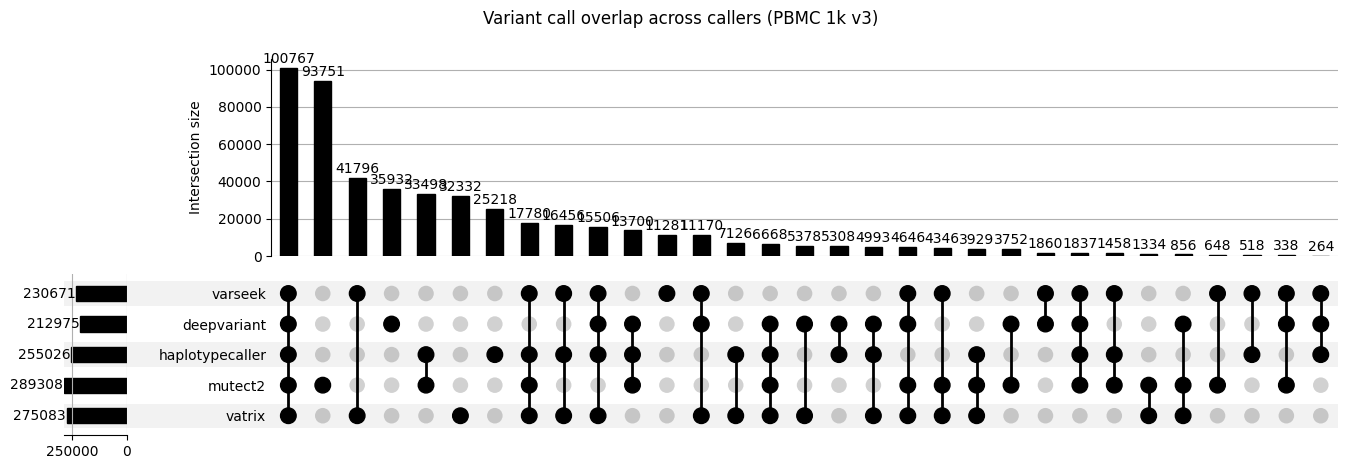

In [30]:
try:
    import upsetplot
except ImportError:
    print("upsetplot not found, installing...")
    !pip install -U -q upsetplot
    import upsetplot

import gzip
import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet


def read_variant_set(vcf_path):
    """Read a (optionally gzipped) VCF into a set of (CHROM, POS, REF, ALT) keys.
    Multiallelic ALTs are split so each allele is counted separately."""
    if not vcf_path or not os.path.exists(vcf_path):
        return None
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    keys = set()
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            for a in alt.split(","):
                keys.add((chrom, pos, ref, a))
    return keys


# Use the normalized (left-aligned, multiallelic-split) VCFs so all four callers
# share a common coordinate representation. varseek is a variant-sites-only set;
# the GATK/DeepVariant callers are filtered to non-reference calls (_nonref) before
# normalization inside compare_with_happy().
caller_vcfs = {
    "varseek": add_normalized_before_first_dot(vk_count_variants_vcf),
    "deepvariant": add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "mutect2": add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref")),
    "vatrix": add_normalized_before_first_dot(vartrix_confirmed_vcf),
    # "bcftools": add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref"))
}

caller_sets = {}
for name, path in caller_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from upset plot.")
        continue
    caller_sets[name] = s
    print(f"{name}: {len(s):,} variants ({path})")

if len(caller_sets) >= 2:
    upset_data = from_contents(caller_sets)
    fig = plt.figure(figsize=(11, 6))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality", sort_categories_by="-input").plot(fig=fig)
    fig.suptitle("Variant call overlap across callers (PBMC 1k v3)")

    upset_png = os.path.join(happy_out, "upset_callers.png")
    os.makedirs(happy_out, exist_ok=True)
    fig.savefig(upset_png, dpi=150, bbox_inches="tight")
    print(f"Saved upset plot to {upset_png}")
    plt.show()
else:
    print("Need at least two caller sets to build an upset plot.")

### Are the variants only Mutect2 detects likely real?

The upset plot above shows that Mutect2 reports a large block of variants that **no other caller** (varseek, DeepVariant, GATK HaplotypeCaller, VarTrix) recovers. Are these genuine variants the other tools miss, or are they mostly Mutect2-specific false positives?

We can't observe ground truth here, but we have three orthogonal lines of evidence:

1. **Corroboration as a proxy for truth.** Split Mutect2's PASS calls into *Mutect2-only* (in Mutect2 and **none** of the other callers) vs. *corroborated* (in Mutect2 **and** ≥1 other caller). Independent methods agreeing makes the corroborated set a reasonable "likely-real" reference, so we ask how the Mutect2-only set differs from it.

2. **Mutect2's own per-call evidence.** Read depth (`DP`), alt-allele read count (`AD`), allele fraction (`AF`), and model confidence (`TLOD`) say how much support each call has. A call resting on a single read is the classic signature of an RNA-seq / sequencing artifact.

3. **Population-genetics signals.** The transition/transversion (Ti/Tv) ratio of true human SNVs is ~2–3, whereas random sequencing errors trend toward ~0.5; and genuine variants in a healthy donor are overwhelmingly germline, so they should appear in the 1000 Genomes catalogue (final cell).

All comparisons use the normalized (`_nonref_normalized`) VCFs, so variant keys line up with the upset plot above.

Union of orthogonal callers: 410,695 variant alleles

Mutect2 PASS alleles: 289,308
  corroborated (>=1 other caller): 195,557 (67.6%)
  mutect2-only (no other caller):  93,751 (32.4%)

Per-call evidence by group:


,mutect2-only,corroborated
n,93751.000,195557.000
% single alt read,68.400,1.525
% indel,5.739,12.167
Ti/Tv (SNVs),2.432,2.868
median DP,1.000,5.000
median alt_AD,1.000,3.000
median AF,0.667,0.750
median TLOD,4.200,8.530
median GERMQ,43.000,45.000
median MPOS,26.000,25.000



Saved figure to data/happy_output/mutect2_only_evidence.png


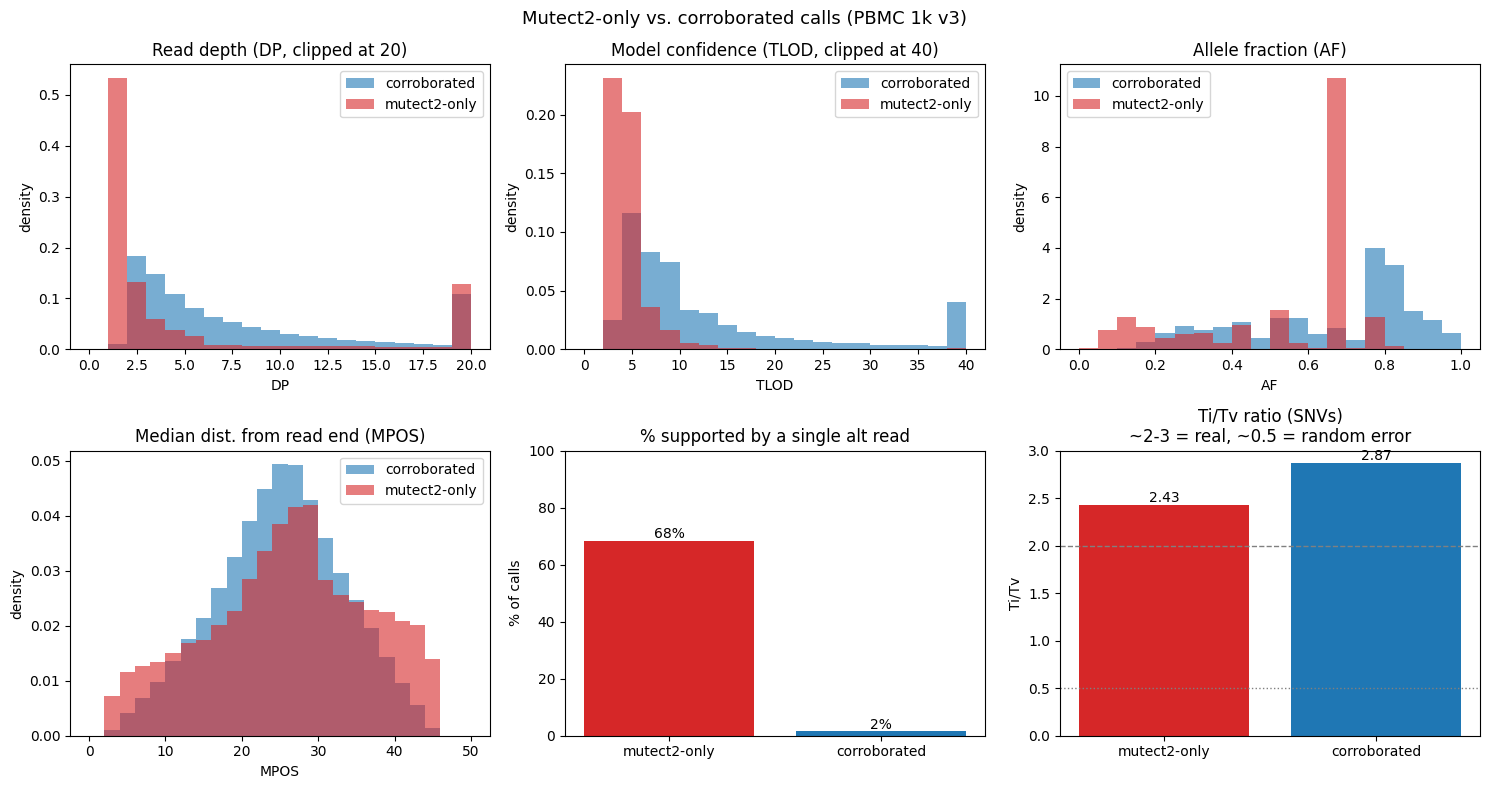

In [31]:
import os
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Partition Mutect2's PASS calls into "mutect2-only" vs "corroborated", using
# the same normalized VCFs the upset plot used so keys line up exactly.
# ---------------------------------------------------------------------------
mutect2_norm = add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref"))

orthogonal_vcfs = {
    "varseek":         add_normalized_before_first_dot(vk_count_variants_vcf),
    "deepvariant":     add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "vartrix":         add_normalized_before_first_dot(vartrix_confirmed_vcf),
}

other_calls = set()
for name, path in orthogonal_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from corroboration set.")
        continue
    other_calls |= s
print(f"Union of orthogonal callers: {len(other_calls):,} variant alleles\n")

# ---------------------------------------------------------------------------
# Parse every Mutect2 record, pulling its per-call evidence, and tag the group.
# Fields: DP/AD/AF (FORMAT, per-sample), TLOD/GERMQ/MPOS/MBQ/MMQ/POPAF (INFO).
# ---------------------------------------------------------------------------
TRANSITIONS = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}

def _info_dict(info):
    return dict(f.split("=", 1) for f in info.split(";") if "=" in f)

def _first(x):
    """First (alt) value of a possibly comma-separated field, as float."""
    try:
        return float(str(x).split(",")[0])
    except (ValueError, AttributeError):
        return np.nan

def _alt(x):
    """Second (alt) value of a ref,alt field (e.g. AD, MBQ, MMQ), as float."""
    try:
        return float(str(x).split(",")[1])
    except (ValueError, IndexError, AttributeError):
        return np.nan

rows = []
with gzip.open(mutect2_norm, "rt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        cols = line.rstrip("\n").split("\t")
        chrom, pos, _id, ref, alt, _qual, _filt, info, fmt, sample = cols[:10]
        key = (chrom, pos, ref, alt)
        sd = dict(zip(fmt.split(":"), sample.split(":")))
        idict = _info_dict(info)
        is_snv = len(ref) == 1 and len(alt) == 1 and ref in "ACGT" and alt in "ACGT"
        rows.append({
            "key": key,
            "group": "corroborated" if key in other_calls else "mutect2-only",
            "is_snv": is_snv,
            "is_indel": len(ref) != len(alt),
            "ti": is_snv and (ref, alt) in TRANSITIONS,
            "tv": is_snv and (ref, alt) not in TRANSITIONS,
            "DP": _first(sd.get("DP")),
            "alt_AD": _alt(sd.get("AD")),
            "AF": _first(sd.get("AF")),
            "TLOD": _first(idict.get("TLOD")),
            "GERMQ": _first(idict.get("GERMQ")),
            "MPOS": _first(idict.get("MPOS")),
            "MBQ_alt": _alt(idict.get("MBQ")),
            "MMQ_alt": _alt(idict.get("MMQ")),
            "POPAF": _first(idict.get("POPAF")),
        })

m2 = pd.DataFrame(rows)
m2["single_read"] = m2["alt_AD"] <= 1   # call rests on a single alt-supporting read

n_only = int((m2["group"] == "mutect2-only").sum())
print(f"Mutect2 PASS alleles: {len(m2):,}")
print(f"  corroborated (>=1 other caller): {len(m2) - n_only:,} ({100*(len(m2)-n_only)/len(m2):.1f}%)")
print(f"  mutect2-only (no other caller):  {n_only:,} ({100*n_only/len(m2):.1f}%)")

# ---------------------------------------------------------------------------
# Per-group summary table.
# ---------------------------------------------------------------------------
def group_summary(df):
    ti, tv = int(df["ti"].sum()), int(df["tv"].sum())
    out = {
        "n": len(df),
        "% single alt read": 100 * df["single_read"].mean(),
        "% indel": 100 * df["is_indel"].mean(),
        "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan,
    }
    for c in ["DP", "alt_AD", "AF", "TLOD", "GERMQ", "MPOS", "MBQ_alt", "MMQ_alt", "POPAF"]:
        out[f"median {c}"] = df[c].median()
    return out

summary = pd.DataFrame(
    {g: group_summary(d) for g, d in m2.groupby("group")}
)[["mutect2-only", "corroborated"]]
print("\nPer-call evidence by group:")
display(summary.round(3))

# ---------------------------------------------------------------------------
# Visual comparison.
# ---------------------------------------------------------------------------
only = m2[m2["group"] == "mutect2-only"]
corr = m2[m2["group"] == "corroborated"]
COL = {"mutect2-only": "#d62728", "corroborated": "#1f77b4"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

def hist_pair(ax, col, bins, title, xlabel, clip=None):
    o = only[col].clip(upper=clip) if clip else only[col]
    c = corr[col].clip(upper=clip) if clip else corr[col]
    ax.hist(c.dropna(), bins=bins, density=True, alpha=0.6, label="corroborated", color=COL["corroborated"])
    ax.hist(o.dropna(), bins=bins, density=True, alpha=0.6, label="mutect2-only", color=COL["mutect2-only"])
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("density"); ax.legend()

hist_pair(axes[0, 0], "DP",   np.arange(0, 21, 1),    "Read depth (DP, clipped at 20)", "DP", clip=20)
hist_pair(axes[0, 1], "TLOD", np.arange(0, 41, 2),    "Model confidence (TLOD, clipped at 40)", "TLOD", clip=40)
hist_pair(axes[0, 2], "AF",   np.linspace(0, 1, 21),  "Allele fraction (AF)", "AF")
hist_pair(axes[1, 0], "MPOS", np.arange(0, 51, 2),    "Median dist. from read end (MPOS)", "MPOS", clip=50)

# % single-read bar
ax = axes[1, 1]
vals = [100 * only["single_read"].mean(), 100 * corr["single_read"].mean()]
ax.bar(["mutect2-only", "corroborated"], vals, color=[COL["mutect2-only"], COL["corroborated"]])
for i, v in enumerate(vals):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
ax.set_title("% supported by a single alt read"); ax.set_ylabel("% of calls"); ax.set_ylim(0, 100)

# Ti/Tv bar
ax = axes[1, 2]
def titv(df):
    ti, tv = int(df["ti"].sum()), int(df["tv"].sum())
    return (ti / tv) if tv else np.nan
vals = [titv(only), titv(corr)]
ax.bar(["mutect2-only", "corroborated"], vals, color=[COL["mutect2-only"], COL["corroborated"]])
for i, v in enumerate(vals):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center")
ax.axhline(2.0, ls="--", c="gray", lw=1)
ax.axhline(0.5, ls=":", c="gray", lw=1)
ax.set_title("Ti/Tv ratio (SNVs)\n~2-3 = real, ~0.5 = random error")
ax.set_ylabel("Ti/Tv"); ax.set_ylim(0, 3)

fig.suptitle("Mutect2-only vs. corroborated calls (PBMC 1k v3)", fontsize=13)
fig.tight_layout()
titv_fig_path = os.path.join(happy_out, "mutect2_only_evidence.png")
fig.savefig(titv_fig_path, dpi=150, bbox_inches="tight")
print(f"\nSaved figure to {titv_fig_path}")
plt.show()

Using cached 1000 Genomes hits: data/happy_output/mutect2_sites_in_1000G.tsv

1000 Genomes phase-3 records matched: 139,359 sites



,n,% on known 1000G site,% exact allele in 1000G
group,,,
mutect2-only,93751,23.40,21.00
corroborated,195557,60.04,59.37



Mutect2-only, stratified by read support:


,n,% on known 1000G site,Ti/Tv (SNVs)
multi-read,29625,14.99,3.78
single-read,64126,27.29,2.12



Saved figure to data/happy_output/mutect2_only_1000G_overlap.png


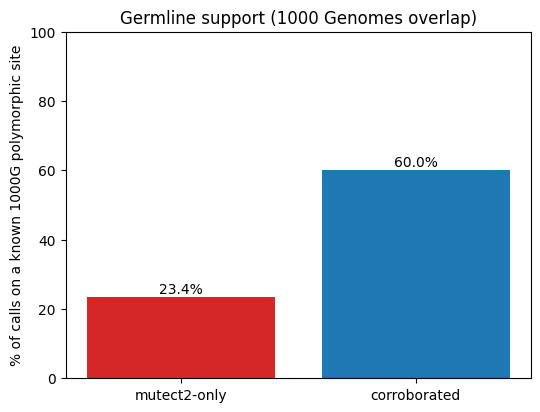

In [32]:
# ---------------------------------------------------------------------------
# Orthogonal germline check: how many Mutect2 calls sit on a known 1000 Genomes
# site? A healthy donor's real variants are overwhelmingly germline, so genuine
# calls should be enriched for known polymorphic sites; artifacts should not.
#
# This streams the (~12 GB) 1000 Genomes VCF once with `bcftools view -T`, which
# does NOT require an index, and caches the matching records. Set to False to skip.
# ---------------------------------------------------------------------------
RUN_GERMLINE_OVERLAP = True

germline_hits_tsv = os.path.join(happy_out, "mutect2_sites_in_1000G.tsv")

if RUN_GERMLINE_OVERLAP and os.path.exists(genomes1000_vcf):
    if not (os.path.isfile(germline_hits_tsv) and os.path.getsize(germline_hits_tsv) > 0):
        # Targets = every unique (CHROM, POS) Mutect2 calls. bcftools -T loads these
        # into an in-memory index, so file order does not matter.
        targets_tsv = os.path.join(happy_out, "mutect2_query_sites.tsv")
        sites = sorted({(k[0], int(k[1])) for k in m2["key"]})
        with open(targets_tsv, "w") as fh:
            fh.writelines(f"{c}\t{p}\n" for c, p in sites)
        print(f"Streaming 1000 Genomes for {len(sites):,} Mutect2 sites "
              f"(one pass over {genomes1000_vcf}, this can take a few minutes)...")
        with open(germline_hits_tsv, "w") as out:
            subprocess.run(["bcftools", "view", "-H", "-T", targets_tsv, genomes1000_vcf],
                           stdout=out, check=True)
    else:
        print(f"Using cached 1000 Genomes hits: {germline_hits_tsv}")

    # Build lookups: known polymorphic SITE (chrom,pos) and exact ALLELE match.
    pos_hits, allele_hits = set(), set()
    with open(germline_hits_tsv) as fh:
        for line in fh:
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            pos_hits.add((chrom, pos))
            for a in alt.split(","):
                allele_hits.add((chrom, pos, ref, a))

    m2["in_1000G_site"] = m2["key"].map(lambda k: (k[0], k[1]) in pos_hits)
    m2["in_1000G_allele"] = m2["key"].map(lambda k: k in allele_hits)

    print(f"\n1000 Genomes phase-3 records matched: {len(pos_hits):,} sites\n")
    g = m2.groupby("group")
    germ = pd.DataFrame({
        "n": g.size(),
        "% on known 1000G site": 100 * g["in_1000G_site"].mean(),
        "% exact allele in 1000G": 100 * g["in_1000G_allele"].mean(),
    }).loc[["mutect2-only", "corroborated"]]
    display(germ.round(2))

    # Within mutect2-only, does the multi-read minority look more germline than
    # the single-read bulk? (i.e. is the "real" signal concentrated where there
    # is more than one supporting read?)
    only = m2[m2["group"] == "mutect2-only"]
    strat = only.groupby(np.where(only["single_read"], "single-read", "multi-read"))
    strat_tbl = pd.DataFrame({
        "n": strat.size(),
        "% on known 1000G site": 100 * strat["in_1000G_site"].mean(),
        "Ti/Tv (SNVs)": strat.apply(
            lambda d: (d["ti"].sum() / d["tv"].sum()) if d["tv"].sum() else np.nan
        ),
    })
    print("\nMutect2-only, stratified by read support:")
    display(strat_tbl.round(2))

    # Plot germline enrichment.
    fig, ax = plt.subplots(figsize=(6, 4.5))
    labels = ["mutect2-only", "corroborated"]
    vals = [germ.loc[l, "% on known 1000G site"] for l in labels]
    bars = ax.bar(labels, vals, color=["#d62728", "#1f77b4"])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center")
    ax.set_ylabel("% of calls on a known 1000G polymorphic site")
    ax.set_title("Germline support (1000 Genomes overlap)")
    ax.set_ylim(0, 100)
    germ_fig_path = os.path.join(happy_out, "mutect2_only_1000G_overlap.png")
    fig.savefig(germ_fig_path, dpi=150, bbox_inches="tight")
    print(f"\nSaved figure to {germ_fig_path}")
    plt.show()
elif not os.path.exists(genomes1000_vcf):
    print(f"1000 Genomes VCF not found at {genomes1000_vcf}; skipping germline overlap.")
else:
    print("RUN_GERMLINE_OVERLAP is False; skipping the 1000 Genomes streaming step.")

#### Takeaway

The three lines of evidence agree on the headline and add a twist.

**Headline — most Mutect2-only calls have little independent support.** About 32% of Mutect2's PASS calls are Mutect2-only, and they look very different from the corroborated set:

- **Read support collapses.** ~68% rest on a *single* alt read (median `DP` = 1, median `TLOD` ≈ 4) versus ~1.5% of corroborated calls (median `DP` = 5). At depth 1, a single sequencing / reverse-transcription error is indistinguishable from a real variant — exactly the calls the other tools' depth/consensus thresholds (and varseek's `min_counts`) reject, which is why they end up Mutect2-private.
- **Germline overlap roughly halves.** Only ~23% of Mutect2-only calls sit on a known 1000 Genomes site, versus ~60% of corroborated calls.
- **Ti/Tv (≈2.4) sits between** the corroborated set (≈2.9) and the random-error floor (~0.5) — a *blend* of real variants and artifacts, not pure noise.

**The twist — the Mutect2-only set is two different non-real populations.** Stratifying by read support shows they are not one thing:

- *Single-read bulk* (~68% of Mutect2-only): lower Ti/Tv (~2.1) but the **higher** 1000G overlap (~27%). These include genuine low-coverage germline SNVs that happen to land on known sites but were dropped by the other callers purely for lack of depth — mixed in with single-read sequencing errors.
- *Multi-read minority* (~32% of Mutect2-only): very high Ti/Tv (~3.8, even above the corroborated set) yet the **lowest** 1000G overlap (~15%). A recurrent, transition-heavy, non-germline signal is the classic fingerprint of RNA-specific events — A-to-I RNA editing (seen as A>G / T>C) and reverse-transcription / mapping artifacts — reproducible at the RNA level but not DNA variants, so absent from 1000 Genomes.

**Bottom line:** few Mutect2-only calls are well-supported DNA variants the other tools genuinely missed. The set is dominated by single-read calls (a mix of low-coverage real germline SNVs and sequencing errors), with a multi-read tail that looks like RNA editing / RT artifacts rather than DNA variation. This is expected — Mutect2 is the most permissive caller in this benchmark, and the other tools' (and varseek's) higher evidence requirements trade a little recall for substantially better precision.